# Simulation 3 Film Cue Inclusion Figure

> Generate the first Simulation 3 figure for intermittent test-phase film cues.

This notebook holds the post-reminder interference condition fixed and varies film cue strength during retrieval.
Cue events are applied after scheduled recall attempts, sample positions from the film sequence, and do not occupy recall slots or add learning.

In [1]:
import csv
import os
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random
from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root

from selective_interference_v2 import (
    PHASE_COLORS,
    Paradigm,
    add_phase_bands,
    batch_trial,
    configure_rates,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    make_is_target,
    prepare_sweep,
    save_figure,
    simulate_periodic_cued_free_recall,
    split_scales_for_cache,
    standard_remap,
    sweep_rngs,
)

warnings.filterwarnings("ignore")

In [2]:
# --- sweep configuration ---
PROJECT_ROOT = ""
FIT_PATH = "results/fits/Dupertuys2026_eCMR_source_only_phi_no_shared_support_best_of_1.json"
FIGURE_DIR = ""
FIGURE_STR = ""
RNG_SEED = 0

SWEEP_VALUES = [0.0, 0.225, 0.45, 0.675, 0.90, 1.125, 1.35, 1.50]
SWEEP_XLABEL = "Film-cue\nreinstatement"
SWEEP_LABEL_FMT = "{:.2f}"

N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
EXPERIMENT_COUNT = 5000
MAX_RECALL = 48
CUE_INTERVAL = 4
FIRST_CUE_AFTER = 4

TASK_MCF_SCALE = 2.0
FILM_EMOTIONAL = True
INTERFERENCE_EMOTIONAL = False
CACHE_AFTER = "filler"
EXTRA_FIXED_SCALES = {
    "source_learning_baseline": 0.05,
    "film_source_start_drift_rate": 0.5,
    "primacy_scale": 0.1,
    "primacy_decay": 1.5,
}

RETRIEVAL_CONDITIONS = {
    "Unguided retrieval": 0.0,
    "Deliberate recall": 1.0,
}

BASE_FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 1.0,
    "reminder_drift_scale": 1.0,
    "interference_mcf_scale": TASK_MCF_SCALE,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

In [3]:
# Parameters
PROJECT_ROOT = "/Users/jordangunn/workspace/selective_interference_v2"
FIGURE_DIR = "figures"
FIGURE_STR = "simulation3_film_cue_inclusion"


In [4]:
#| output: asis
if PROJECT_ROOT:
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(find_project_root())

fit_path = project_root / FIT_PATH
figure_dir = project_root / FIGURE_DIR if FIGURE_DIR else None
sweep_values = np.asarray(SWEEP_VALUES, dtype=float)
base_fixed_scales = {**BASE_FIXED_SCALES, **EXTRA_FIXED_SCALES}

params, n_subjects = load_fit_params(fit_path)
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
    max_recall=MAX_RECALL,
)
factory = make_factory(
    is_emotional=make_is_emotional(
        paradigm,
        film_emotional=FILM_EMOTIONAL,
        interference_emotional=INTERFERENCE_EMOTIONAL,
    ),
    is_target=make_is_target(paradigm),
)
rng = random.PRNGKey(RNG_SEED)

Markdown(
    f"Loaded {n_subjects} fit parameter set(s). Running {len(sweep_values)} film-cue values "
    f"across {len(RETRIEVAL_CONDITIONS)} retrieval conditions with {EXPERIMENT_COUNT} simulated trials per value."
)

Loaded 1 fit parameter set(s). Running 8 film-cue values across 2 retrieval conditions with 5000 simulated trials per value.

In [5]:
def position_phase_labels(paradigm):
    return (
        ["film"] * paradigm.n_film
        + ["break"] * paradigm.n_break
        + ["task"] * paradigm.n_interference
        + ["filler"] * paradigm.n_filler
    )


def write_rows(path, fieldnames, rows):
    os.makedirs(path.parent, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def phase_recall_totals(spc):
    totals = {}
    for phase in sorted(set(position_phase)):
        positions = [idx for idx, value in enumerate(position_phase) if value == phase]
        totals[phase] = float(np.sum(spc[positions]))
    return totals


def cue_position_bin(cue_position):
    if 1 <= cue_position <= 5:
        return "early"
    if 6 <= cue_position <= 11:
        return "middle"
    if 12 <= cue_position <= 16:
        return "late"
    return "none"


def first_cue_by_trial(cue_items):
    flat = cue_items.reshape(-1, cue_items.shape[-1])
    first_items = []
    first_attempts = []
    for row in flat:
        nonzero = np.flatnonzero(row > 0)
        if nonzero.size == 0:
            first_items.append(0)
            first_attempts.append(0)
        else:
            idx = int(nonzero[0])
            first_items.append(int(row[idx]))
            first_attempts.append(idx + 1)
    return np.asarray(first_items), np.asarray(first_attempts)


def summarize_first_cue_bins(recalls, cue_items, retrieval_condition, cue_scale):
    flat_recalls = recalls.reshape(-1, recalls.shape[-1])
    first_items, first_attempts = first_cue_by_trial(cue_items)
    rows = []
    for cue_bin in ["early", "middle", "late", "none"]:
        trial_mask = np.asarray([cue_position_bin(item) == cue_bin for item in first_items])
        trial_count = int(np.sum(trial_mask))
        if trial_count == 0:
            rows.append({
                "retrieval_condition": retrieval_condition,
                "film_cue_reinstatement": cue_scale,
                "first_cue_bin": cue_bin,
                "trial_count": 0,
                "post_cue_film_mass": np.nan,
                "post_cue_task_mass": np.nan,
                "post_cue_film_share": np.nan,
            })
            continue
        film_counts = []
        task_counts = []
        for row, first_attempt in zip(flat_recalls[trial_mask], first_attempts[trial_mask]):
            if first_attempt == 0:
                post_cue = row
            else:
                post_cue = row[first_attempt:]
            film_counts.append(np.sum((post_cue >= 1) & (post_cue <= paradigm.n_film)))
            task_start = paradigm.n_film + paradigm.n_break + 1
            task_end = task_start + paradigm.n_interference - 1
            task_counts.append(np.sum((post_cue >= task_start) & (post_cue <= task_end)))
        film_mass = float(np.mean(film_counts))
        task_mass = float(np.mean(task_counts))
        denom = film_mass + task_mass
        film_share = np.nan if denom == 0 else film_mass / denom
        rows.append({
            "retrieval_condition": retrieval_condition,
            "film_cue_reinstatement": cue_scale,
            "first_cue_bin": cue_bin,
            "trial_count": trial_count,
            "post_cue_film_mass": film_mass,
            "post_cue_task_mass": task_mass,
            "post_cue_film_share": film_share,
        })
    return rows


def cue_position_count_rows(cue_items, retrieval_condition, cue_scale):
    flat = cue_items.reshape(-1, cue_items.shape[-1])
    rows = []
    scheduled_indices = np.arange(FIRST_CUE_AFTER - 1, flat.shape[1], CUE_INTERVAL)
    for event_number, event_index in enumerate(scheduled_indices, start=1):
        values, counts = np.unique(flat[:, event_index], return_counts=True)
        count_by_position = {int(value): int(count) for value, count in zip(values, counts)}
        for cue_position in range(1, paradigm.n_film + 1):
            rows.append({
                "retrieval_condition": retrieval_condition,
                "film_cue_reinstatement": cue_scale,
                "cue_event_number": event_number,
                "cue_position": cue_position,
                "cue_bin": cue_position_bin(cue_position),
                "count": count_by_position.get(cue_position, 0),
            })
    return rows


position_phase = position_phase_labels(paradigm)
n_presented = len(position_phase)

In [6]:
def cued_recall_trial(
    model,
    rng,
    film_items,
    cue_scale,
    max_recall,
    cue_interval,
    first_cue_after,
):
    model = model.start_retrieving()
    _, recalls, cue_attempts, cue_items = simulate_periodic_cued_free_recall(
        model,
        max_recall,
        rng,
        film_items,
        cue_scale,
        cue_interval=cue_interval,
        first_cue_after=first_cue_after,
    )
    return recalls, cue_attempts, cue_items


batched_cued_recall = batch_trial(cued_recall_trial, n_args=7, n_static=3)
pre_cache_scales, post_cache_scales = split_scales_for_cache(
    base_fixed_scales,
    CACHE_AFTER,
)
prepared = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after=CACHE_AFTER,
    **pre_cache_scales,
)

condition_outputs = {}
for retrieval_condition, start_drift_scale in RETRIEVAL_CONDITIONS.items():
    ready_models = configure_rates(
        prepared.models,
        **post_cache_scales,
        start_drift_scale=start_drift_scale,
        rejected_recall_drift_scale=1.0,
    )
    for cue_scale in sweep_values:
        rngs, rng = sweep_rngs(rng, prepared.n_subjects, prepared.experiment_count)
        recalls, cue_attempts, cue_items = batched_cued_recall(
            ready_models,
            rngs,
            paradigm.film_items,
            float(cue_scale),
            paradigm.max_recall,
            CUE_INTERVAL,
            FIRST_CUE_AFTER,
        )
        condition_outputs[(retrieval_condition, float(cue_scale))] = {
            "recalls": np.asarray(recalls),
            "cue_attempts": np.asarray(cue_attempts),
            "cue_items": np.asarray(cue_items),
        }

In [7]:
spc_rows = []
phase_rows = []
cue_bin_rows = []
cue_position_rows = []
spc_curves = {condition: [] for condition in RETRIEVAL_CONDITIONS}

for retrieval_condition in RETRIEVAL_CONDITIONS:
    for cue_scale in sweep_values:
        output = condition_outputs[(retrieval_condition, float(cue_scale))]
        raw_recalls = output["recalls"].reshape(-1, output["recalls"].shape[-1])
        remapped_recalls = np.asarray(
            standard_remap(
                raw_recalls,
                paradigm,
                show_break=True,
            )
        )
        spc = np.asarray(fixed_pres_spc(remapped_recalls, n_presented), dtype=float)
        totals = phase_recall_totals(spc)
        spc_curves[retrieval_condition].append(spc)

        for position, phase in enumerate(position_phase, start=1):
            spc_rows.append({
                "retrieval_condition": retrieval_condition,
                "film_cue_reinstatement": float(cue_scale),
                "position": position,
                "phase": phase,
                "recall_probability": spc[position - 1],
            })
        for phase, total in totals.items():
            phase_rows.append({
                "retrieval_condition": retrieval_condition,
                "film_cue_reinstatement": float(cue_scale),
                "phase": phase,
                "recall_probability_mass": total,
            })
        cue_bin_rows.extend(
            summarize_first_cue_bins(
                output["recalls"],
                output["cue_items"],
                retrieval_condition,
                float(cue_scale),
            )
        )
        cue_position_rows.extend(
            cue_position_count_rows(
                output["cue_items"],
                retrieval_condition,
                float(cue_scale),
            )
        )

In [8]:
if figure_dir is not None and FIGURE_STR:
    write_rows(
        figure_dir / f"{FIGURE_STR}_spc.csv",
        [
            "retrieval_condition",
            "film_cue_reinstatement",
            "position",
            "phase",
            "recall_probability",
        ],
        spc_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_phase_totals.csv",
        [
            "retrieval_condition",
            "film_cue_reinstatement",
            "phase",
            "recall_probability_mass",
        ],
        phase_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_cue_bin_summary.csv",
        [
            "retrieval_condition",
            "film_cue_reinstatement",
            "first_cue_bin",
            "trial_count",
            "post_cue_film_mass",
            "post_cue_task_mass",
            "post_cue_film_share",
        ],
        cue_bin_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_cue_position_counts.csv",
        [
            "retrieval_condition",
            "film_cue_reinstatement",
            "cue_event_number",
            "cue_position",
            "cue_bin",
            "count",
        ],
        cue_position_rows,
    )

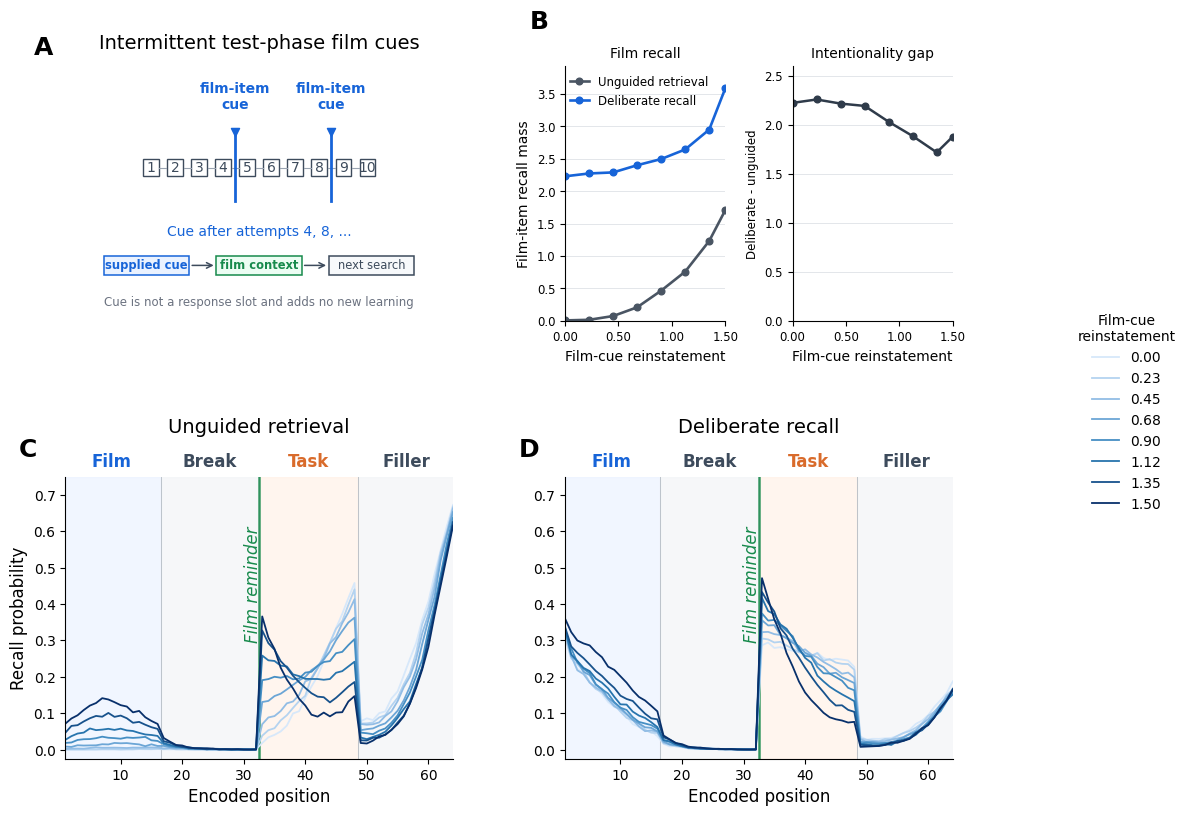

In [9]:
PANEL_LETTER_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 14
STRUCTURAL_FONTSIZE = 12
SUPPORT_FONTSIZE = 10


CONDITION_COLORS = {
    "Unguided retrieval": "#4A5563",
    "Deliberate recall": PHASE_COLORS["film"],
}


def add_panel_label(axis, label, x=-0.12, y=1.14):
    axis.text(
        x,
        y,
        label,
        transform=axis.transAxes,
        fontsize=PANEL_LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


def add_phase_boundaries(axis):
    boundaries = np.cumsum([
        paradigm.n_film,
        paradigm.n_break,
        paradigm.n_interference,
    ]) + 0.5
    for boundary in boundaries:
        axis.axvline(boundary, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)


def add_reminder_marker(axis, show_label=True):
    reminder_x = paradigm.n_film + paradigm.n_break + 0.5
    axis.axvline(
        reminder_x,
        color=PHASE_COLORS["reminder"],
        linewidth=1.8,
        alpha=0.85,
        zorder=2,
    )
    if show_label:
        axis.text(
            reminder_x - 1.05,
            0.62,
            "Film reminder",
            ha="center",
            va="center",
            fontsize=STRUCTURAL_FONTSIZE,
            fontstyle="italic",
            color=PHASE_COLORS["reminder"],
            rotation=90,
            rotation_mode="anchor",
            transform=axis.get_xaxis_transform(),
            clip_on=False,
            zorder=3,
        )


def plot_spc_panel(axis, retrieval_condition, title, show_reminder_label=False):
    add_phase_bands(axis, position_phase, fontsize=STRUCTURAL_FONTSIZE)
    add_phase_boundaries(axis)
    add_reminder_marker(axis, show_label=show_reminder_label)
    colors = light_to_dark_colors(len(sweep_values))
    positions = np.arange(1, n_presented + 1)
    for color, cue_scale, curve in zip(colors, sweep_values, spc_curves[retrieval_condition]):
        axis.plot(
            positions,
            curve,
            color=color,
            linewidth=1.3,
            label=SWEEP_LABEL_FMT.format(cue_scale),
        )
    axis.set_title(title, fontsize=PANEL_TITLE_FONTSIZE, pad=32)
    axis.set_xlabel("Encoded position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel("Recall probability", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(1, n_presented)
    axis.set_ylim(-0.025, 0.75)
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def plot_paradigm_extension(axis):
    axis.axis("off")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.set_title("Intermittent test-phase film cues", fontsize=PANEL_TITLE_FONTSIZE, pad=12)

    x0 = 0.221
    step = 0.062
    y = 0.60
    cue_after = {4, 8}
    for attempt in range(1, 11):
        x = x0 + (attempt - 1) * step
        axis.add_patch(
            plt.Rectangle(
                (x - 0.020, y - 0.034),
                0.040,
                0.068,
                facecolor="white",
                edgecolor="#3D4B5C",
                linewidth=1.0,
            )
        )
        axis.text(x, y, str(attempt), ha="center", va="center", fontsize=SUPPORT_FONTSIZE, color="#3D4B5C")
        if attempt < 10:
            axis.plot([x + 0.022, x + step - 0.022], [y, y], color="#9AA4B2", linewidth=0.8)
        if attempt in cue_after:
            pulse_x = x + step / 2
            axis.plot([pulse_x, pulse_x], [y - 0.13, y + 0.14], color=PHASE_COLORS["film"], linewidth=2.0)
            axis.scatter([pulse_x], [y + 0.14], marker="v", s=34, color=PHASE_COLORS["film"], zorder=3)
            axis.text(
                pulse_x,
                y + 0.22,
                "film\ncue",
                ha="center",
                va="bottom",
                fontsize=SUPPORT_FONTSIZE,
                color=PHASE_COLORS["film"],
                fontweight="bold",
            )

    axis.text(
        0.50,
        0.35,
        f"Cue after attempts {FIRST_CUE_AFTER}, {FIRST_CUE_AFTER + CUE_INTERVAL}, ...",
        ha="center",
        va="center",
        fontsize=SUPPORT_FONTSIZE,
        color=PHASE_COLORS["film"],
    )

    schematic_y = 0.18
    box_h = 0.075
    box_specs = [
        (0.10, 0.22, "supplied cue", PHASE_COLORS["film"], "#EAF2FF"),
        (0.39, 0.22, "film context", PHASE_COLORS["reminder"], "#ECFDF3"),
        (0.68, 0.22, "next search", "#3D4B5C", "#F7F9FB"),
    ]
    for x, width, label, color, fill in box_specs:
        axis.add_patch(
            plt.Rectangle(
                (x, schematic_y),
                width,
                box_h,
                facecolor=fill,
                edgecolor=color,
                linewidth=1.1,
            )
        )
        axis.text(
            x + width / 2,
            schematic_y + box_h / 2,
            label,
            ha="center",
            va="center",
            fontsize=8.3,
            color=color,
            fontweight="bold" if color != "#3D4B5C" else "normal",
        )
    axis.annotate(
        "",
        xy=(0.39, schematic_y + box_h / 2),
        xytext=(0.32, schematic_y + box_h / 2),
        arrowprops={"arrowstyle": "->", "linewidth": 1.1, "color": "#3D4B5C"},
    )
    axis.annotate(
        "",
        xy=(0.68, schematic_y + box_h / 2),
        xytext=(0.61, schematic_y + box_h / 2),
        arrowprops={"arrowstyle": "->", "linewidth": 1.1, "color": "#3D4B5C"},
    )

    muted = "#6B7280"
    axis.text(
        0.50,
        0.075,
        "Cue is not a response slot and adds no new learning",
        ha="center",
        va="center",
        fontsize=8.5,
        color=muted,
    )

def phase_total(retrieval_condition, cue_scale, phase):
    matches = [
        row for row in phase_rows
        if row["retrieval_condition"] == retrieval_condition
        and np.isclose(row["film_cue_reinstatement"], cue_scale)
        and row["phase"] == phase
    ]
    if not matches:
        return np.nan
    return matches[0]["recall_probability_mass"]


def plot_film_mass_panel(recall_axis, gap_axis):
    film_by_condition = {}
    for retrieval_condition in RETRIEVAL_CONDITIONS:
        values = np.asarray([
            phase_total(retrieval_condition, cue_scale, "film")
            for cue_scale in sweep_values
        ])
        film_by_condition[retrieval_condition] = values
        recall_axis.plot(
            sweep_values,
            values,
            marker="o",
            linewidth=1.9,
            markersize=4.8,
            color=CONDITION_COLORS[retrieval_condition],
            label=retrieval_condition,
        )
    gap = film_by_condition["Deliberate recall"] - film_by_condition["Unguided retrieval"]
    gap_axis.plot(
        sweep_values,
        gap,
        marker="o",
        linewidth=1.8,
        markersize=4.8,
        color="#2F3B4A",
    )

    recall_axis.set_title("Film recall", fontsize=SUPPORT_FONTSIZE, pad=6)
    recall_axis.set_xlabel("Film cue strength", fontsize=SUPPORT_FONTSIZE)
    recall_axis.set_ylabel("Film recall mass", fontsize=SUPPORT_FONTSIZE)
    recall_axis.set_xlim(float(np.min(sweep_values)), float(np.max(sweep_values)))
    recall_axis.set_ylim(0, max(3.25, float(np.nanmax([*film_by_condition.values()])) + 0.35))
    x_ticks = np.linspace(float(np.min(sweep_values)), float(np.max(sweep_values)), 4)
    recall_axis.set_xticks(x_ticks)
    recall_axis.set_xticklabels([f"{value:.2f}" for value in x_ticks])
    recall_axis.tick_params(labelsize=8.5)
    recall_axis.grid(axis="y", color="#D6DBE1", linewidth=0.7, alpha=0.7)
    recall_axis.spines["top"].set_visible(False)
    recall_axis.spines["right"].set_visible(False)
    recall_axis.legend(
        frameon=False,
        fontsize=8.5,
        loc="upper left",
        bbox_to_anchor=(0.00, 0.98),
        borderaxespad=0.0,
        handlelength=1.6,
    )

    gap_axis.set_title("Intentionality gap", fontsize=SUPPORT_FONTSIZE, pad=6)
    gap_axis.set_xlabel("Film cue strength", fontsize=SUPPORT_FONTSIZE)
    gap_axis.set_ylabel("Deliberate - unguided", fontsize=8.5)
    gap_axis.set_xlim(float(np.min(sweep_values)), float(np.max(sweep_values)))
    gap_axis.set_ylim(0, max(2.6, float(np.nanmax(gap)) + 0.25))
    gap_axis.set_xticks(x_ticks)
    gap_axis.set_xticklabels([f"{value:.2f}" for value in x_ticks])
    gap_axis.tick_params(labelsize=8.5)
    gap_axis.grid(axis="y", color="#D6DBE1", linewidth=0.7, alpha=0.7)
    gap_axis.spines["top"].set_visible(False)
    gap_axis.spines["right"].set_visible(False)


fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 1, 1, 1, 0.62],
    height_ratios=[0.95, 1.05],
    hspace=0.58,
    wspace=0.88,
)

axis_a = fig.add_subplot(gs[0, 0:2])
gs_b = gs[0, 2:4].subgridspec(1, 2, wspace=0.42)
axis_b = fig.add_subplot(gs_b[0])
axis_b_gap = fig.add_subplot(gs_b[1])
axis_c = fig.add_subplot(gs[1, 0:2])
axis_d = fig.add_subplot(gs[1, 2:4], sharex=axis_c, sharey=axis_c)
legend_axis = fig.add_subplot(gs[:, 4])
legend_axis.axis("off")

plot_paradigm_extension(axis_a)
plot_film_mass_panel(axis_b, axis_b_gap)
plot_spc_panel(axis_c, "Unguided retrieval", "Unguided retrieval", show_reminder_label=True)
plot_spc_panel(axis_d, "Deliberate recall", "Deliberate recall", show_reminder_label=True)
axis_d.set_ylabel("")

add_panel_label(axis_a, "A", x=-0.08, y=1.12)
add_panel_label(axis_b, "B", x=-0.22, y=1.22)
add_panel_label(axis_c, "C")
add_panel_label(axis_d, "D")

handles, labels = axis_c.get_legend_handles_labels()
legend = legend_axis.legend(
    handles,
    labels,
    title=SWEEP_XLABEL,
    loc="center left",
    fontsize=SUPPORT_FONTSIZE,
    title_fontsize=SUPPORT_FONTSIZE,
    frameon=False,
)
legend.get_title().set_multialignment("center")
legend.get_title().set_ha("center")

save_figure(str(figure_dir) if figure_dir is not None else "", FIGURE_STR)


In [10]:
diagnostic_rows = []
for retrieval_condition in RETRIEVAL_CONDITIONS:
    for cue_scale in sweep_values:
        totals = [
            row for row in phase_rows
            if row["retrieval_condition"] == retrieval_condition
            and np.isclose(row["film_cue_reinstatement"], cue_scale)
        ]
        film_total = next(row["recall_probability_mass"] for row in totals if row["phase"] == "film")
        task_total = next(row["recall_probability_mass"] for row in totals if row["phase"] == "task")
        diagnostic_rows.append((retrieval_condition, cue_scale, film_total, task_total))

diagnostic_rows[:6]

[('Unguided retrieval',
  np.float64(0.0),
  0.007599999982630834,
  3.0455999989062548),
 ('Unguided retrieval',
  np.float64(0.225),
  0.016800000157672912,
  3.2194000110030174),
 ('Unguided retrieval',
  np.float64(0.45),
  0.07479999959468842,
  3.3615999817848206),
 ('Unguided retrieval',
  np.float64(0.675),
  0.20960000017657876,
  3.6032000184059143),
 ('Unguided retrieval',
  np.float64(0.9),
  0.46659999527037144,
  3.6376000195741653),
 ('Unguided retrieval',
  np.float64(1.125),
  0.7599999941885471,
  3.4811999946832657)]